# Iris - classification

In this notebook, I present a performance comparison of six classical machine learning classification algorithms:
- Nearest Centroid,
- k-Nearest Neighbors,
- Naive Bayes,
- Decision Tree,
- Random Forest,
- Support Vector Machine

and a Neural Network (Multi-layer Perceptron) on an Iris dataset.

Since the dataset is small (150 samples), Leave-One-Out Cross-Validation (LOOCV) is performed to evaluate the accuracy of different models and compare them without random impact. Fit and score times are also saved and their averages are used later to compare the models.

From the EDA we know that class 'Iris setosa' can be very easily separated from the other two classes by a boundary condition petal_length = 2.45.

Note that I use my own python library `ml_lib` in order to show technical skills and a full control under the project.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import ml_lib.prepare as ml_prep
import ml_lib.train as ml_train

from sklearn.neighbors import NearestCentroid, KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

## Data preparation

In [ ]:
# set the path to the raw dataset according to your case
dataset_path = "iris.data"

# set random state variable for reproducibility
RANDOM_STATE = 42

# read the dataset and remove empty lines
with open(dataset_path, "r") as f:
    data = [line.strip() for line in f.readlines() if line.strip() != ""]

# extract features (x) and labels (y) to the numpy arrays
x = ml_prep.extract_features(data, separator=',', indices=range(4), dtype=float)
y = ml_prep.extract_labels(data, separator=',', index=-1)

## Training and evaluation

### 1. Nearest Centroid

In [3]:
models_nc = [
    ml_train.Model(name="Nearest Centroid - Euclidean", model=NearestCentroid(metric='euclidean'), n_scores=len(y)),
    ml_train.Model(name="Nearest Centroid - Manhattan", model=NearestCentroid(metric='manhattan'), n_scores=len(y)),
]

for split_index in range(len(y)):
    x_train, y_train, x_text, y_test = ml_prep.train_test_split_cv(x, y, split_index, len(y))
    for m in models_nc:
        m.accuracy[split_index], m.fit_time[split_index], m.score_time[split_index] = ml_train.run(x_train, y_train, x_text, y_test, m.model)

for m in models_nc:
    print(m.name, np.round(m.accuracy.mean(), 4), np.round(m.fit_time.mean(), 4), np.round(m.score_time.mean(), 4))

Nearest Centroid - Euclidean 0.92 0.0008 0.0177
Nearest Centroid - Manhattan 0.92 0.0009 0.0022


### 2. k-Nearest Neighbors

In [4]:
models_nn = [
    ml_train.Model(name="1-NN", model=KNeighborsClassifier(n_neighbors=1), n_scores=len(y)),
    ml_train.Model(name="3-NN", model=KNeighborsClassifier(n_neighbors=3), n_scores=len(y)),
    ml_train.Model(name="5-NN", model=KNeighborsClassifier(n_neighbors=5), n_scores=len(y)),
    ml_train.Model(name="7-NN", model=KNeighborsClassifier(n_neighbors=7), n_scores=len(y)),
    ml_train.Model(name="9-NN", model=KNeighborsClassifier(n_neighbors=9), n_scores=len(y)),
]

for split_index in range(len(y)):
    x_train, y_train, x_text, y_test = ml_prep.train_test_split_cv(x, y, split_index, len(y))
    for m in models_nn:
        m.accuracy[split_index], m.fit_time[split_index], m.score_time[split_index] = ml_train.run(x_train, y_train, x_text, y_test, m.model)

for m in models_nn:
    print(m.name, np.round(m.accuracy.mean(), 4), np.round(m.fit_time.mean(), 4), np.round(m.score_time.mean(), 4))

1-NN 0.96 0.0016 0.0025
3-NN 0.96 0.0008 0.003
5-NN 0.9667 0.0012 0.0029
7-NN 0.9667 0.0009 0.0022
9-NN 0.9667 0.0006 0.0018


### 3. Naive Bayes

In [5]:
models_nb = [
    ml_train.Model(name="GaussianNB", model=GaussianNB(), n_scores=len(y)),
]

for split_index in range(len(y)):
    x_train, y_train, x_text, y_test = ml_prep.train_test_split_cv(x, y, split_index, len(y))
    for m in models_nb:
        m.accuracy[split_index], m.fit_time[split_index], m.score_time[split_index] = ml_train.run(x_train, y_train, x_text, y_test, m.model)

for m in models_nb:
    print(m.name, np.round(m.accuracy.mean(), 4), np.round(m.fit_time.mean(), 4), np.round(m.score_time.mean(), 4))

GaussianNB 0.9533 0.0015 0.0009


### 4. Decision Tree

In [6]:
models_dt = [
    ml_train.Model(name="Decision Tree - gini", model=DecisionTreeClassifier(criterion='gini', random_state=RANDOM_STATE), n_scores=len(y)),
    ml_train.Model(name="Decision Tree - entropy", model=DecisionTreeClassifier(criterion='entropy', random_state=RANDOM_STATE), n_scores=len(y)),
]

for split_index in range(len(y)):
    x_train, y_train, x_text, y_test = ml_prep.train_test_split_cv(x, y, split_index, len(y))
    for m in models_dt:
        m.accuracy[split_index], m.fit_time[split_index], m.score_time[split_index] = ml_train.run(x_train, y_train, x_text, y_test, m.model)

for m in models_dt:
    print(m.name, np.round(m.accuracy.mean(), 4), np.round(m.fit_time.mean(), 4), np.round(m.score_time.mean(), 4))

Decision Tree - gini 0.94 0.0012 0.0008
Decision Tree - entropy 0.94 0.0017 0.0009


### 5. Random Forest

In [7]:
models_rf = [
    ml_train.Model(name="Random Forest - 5 estimators", model=RandomForestClassifier(n_estimators=5, random_state=RANDOM_STATE), n_scores=len(y)),
    ml_train.Model(name="Random Forest - 10 estimators", model=RandomForestClassifier(n_estimators=10, random_state=RANDOM_STATE), n_scores=len(y)),
    ml_train.Model(name="Random Forest - 20 estimators", model=RandomForestClassifier(n_estimators=20, random_state=RANDOM_STATE), n_scores=len(y)),
    ml_train.Model(name="Random Forest - 50 estimators", model=RandomForestClassifier(n_estimators=50, random_state=RANDOM_STATE), n_scores=len(y)),
]

for split_index in range(len(y)):
    x_train, y_train, x_text, y_test = ml_prep.train_test_split_cv(x, y, split_index, len(y))
    for m in models_rf:
        m.accuracy[split_index], m.fit_time[split_index], m.score_time[split_index] = ml_train.run(x_train, y_train, x_text, y_test, m.model)

for m in models_rf:
    print(m.name, np.round(m.accuracy.mean(), 4), np.round(m.fit_time.mean(), 4), np.round(m.score_time.mean(), 4))

Random Forest - 5 estimators 0.9533 0.0125 0.0017
Random Forest - 10 estimators 0.96 0.0227 0.0018
Random Forest - 20 estimators 0.9667 0.0417 0.0032
Random Forest - 50 estimators 0.96 0.1003 0.0064


### 6. Support Vector Machine

In [8]:
models_svm = [
    ml_train.Model(name="SVM - linear, C=0.25", model=SVC(kernel='linear', C=0.25, random_state=RANDOM_STATE), n_scores=len(y)),
    ml_train.Model(name="SVM - linear, C=1.0", model=SVC(kernel='linear', C=1.0, random_state=RANDOM_STATE), n_scores=len(y)),
    ml_train.Model(name="SVM - linear, C=2.0", model=SVC(kernel='linear', C=2.0, random_state=RANDOM_STATE), n_scores=len(y)),
    ml_train.Model(name="SVM - rbf, C=1.0, gamma=0.01", model=SVC(kernel='rbf', C=1.0, gamma=0.01, random_state=RANDOM_STATE), n_scores=len(y)),
    ml_train.Model(name="SVM - rbf, C=1.0, gamma=0.1", model=SVC(kernel='rbf', C=1.0, gamma=0.1, random_state=RANDOM_STATE), n_scores=len(y)),
    ml_train.Model(name="SVM - rbf, C=1.0, gamma=0.25", model=SVC(kernel='rbf', C=1.0, gamma=0.25, random_state=RANDOM_STATE), n_scores=len(y))
]

for split_index in range(len(y)):
    x_train, y_train, x_text, y_test = ml_prep.train_test_split_cv(x, y, split_index, len(y))
    for m in models_svm:
        m.accuracy[split_index], m.fit_time[split_index], m.score_time[split_index] = ml_train.run(x_train, y_train, x_text, y_test, m.model)

for m in models_svm:
    print(m.name, np.round(m.accuracy.mean(), 4), np.round(m.fit_time.mean(), 4), np.round(m.score_time.mean(), 4))

SVM - linear, C=0.25 0.9733 0.0018 0.0017
SVM - linear, C=1.0 0.98 0.0021 0.002
SVM - linear, C=2.0 0.9733 0.0015 0.0012
SVM - rbf, C=1.0, gamma=0.01 0.94 0.0021 0.001
SVM - rbf, C=1.0, gamma=0.1 0.9733 0.0023 0.0012
SVM - rbf, C=1.0, gamma=0.25 0.9733 0.002 0.0012


### 7. Neural network

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

models_mlp = [
    ml_train.Model(
        name="MLP - hidden layers (4, ), activation relu",
        model=Pipeline([
            ('scaler', StandardScaler()),
            ('mlp', MLPClassifier(
                hidden_layer_sizes=(4, ),
                activation='relu',
                solver='lbfgs',
                alpha=1e-2,
                max_iter=2000,
                tol=1e-4,
                random_state=RANDOM_STATE,
            ))
        ]),
        n_scores=len(y)),
    ml_train.Model(
        name="MLP - hidden layers (8, ), activation relu",
        model=Pipeline([
            ('scaler', StandardScaler()),
            ('mlp', MLPClassifier(
                hidden_layer_sizes=(8, ),
                activation='relu',
                solver='lbfgs',
                alpha=1e-2,
                max_iter=2000,
                tol=1e-4,
                random_state=RANDOM_STATE,
            ))
        ]),
        n_scores=len(y)),
    ml_train.Model(
        name="MLP - hidden layers (16, ), activation relu",
        model=Pipeline([
            ('scaler', StandardScaler()),
            ('mlp', MLPClassifier(
                hidden_layer_sizes=(16, ),
                activation='relu',
                solver='lbfgs',
                alpha=1e-2,
                max_iter=2000,
                tol=1e-4,
                random_state=RANDOM_STATE,
            ))
        ]),
        n_scores=len(y)),
    ml_train.Model(
        name="MLP - hidden layers (8, 6), activation relu",
        model=Pipeline([
            ('scaler', StandardScaler()),
            ('mlp', MLPClassifier(
                hidden_layer_sizes=(8, 6),
                activation='relu',
                solver='lbfgs',
                alpha=1e-2,
                max_iter=2000,
                tol=1e-4,
                random_state=RANDOM_STATE,
            ))
        ]),
        n_scores=len(y)),
    ml_train.Model(
        name="MLP - hidden layers (16, 6), activation relu",
        model=Pipeline([
            ('scaler', StandardScaler()),
            ('mlp', MLPClassifier(
                hidden_layer_sizes=(16, 6),
                activation='relu',
                solver='lbfgs',
                alpha=1e-2,
                max_iter=2000,
                tol=1e-4,
                random_state=RANDOM_STATE,
            ))
        ]),
        n_scores=len(y)),
]

for split_index in range(len(y)):
    x_train, y_train, x_text, y_test = ml_prep.train_test_split_cv(x, y, split_index, len(y))
    for m in models_mlp:
        m.accuracy[split_index], m.fit_time[split_index], m.score_time[split_index] = ml_train.run(x_train, y_train, x_text, y_test, m.model)

for m in models_mlp:
    print(m.name, np.round(m.accuracy.mean(), 4), np.round(m.fit_time.mean(), 4), np.round(m.score_time.mean(), 4))

MLP - hidden layers (4, ), activation relu 0.9667 0.102 0.0021
MLP - hidden layers (8, ), activation relu 0.9667 0.0789 0.0022
MLP - hidden layers (16, ), activation relu 0.96 0.174 0.0021
MLP - hidden layers (8, 6), activation relu 0.9667 0.1392 0.0014
MLP - hidden layers (16, 6), activation relu 0.94 0.2912 0.0017


## Comparison

In [10]:
models = models_nc + models_nn + models_nb + models_dt + models_rf + models_svm + models_mlp
names = [m.name for m in models]
accuracies = [np.round(m.accuracy.mean(), 4) for m in models]
fit_times = [np.round(m.fit_time.mean(), 4) for m in models]
score_times = [np.round(m.score_time.mean(), 4) for m in models]

### Highest accuracy

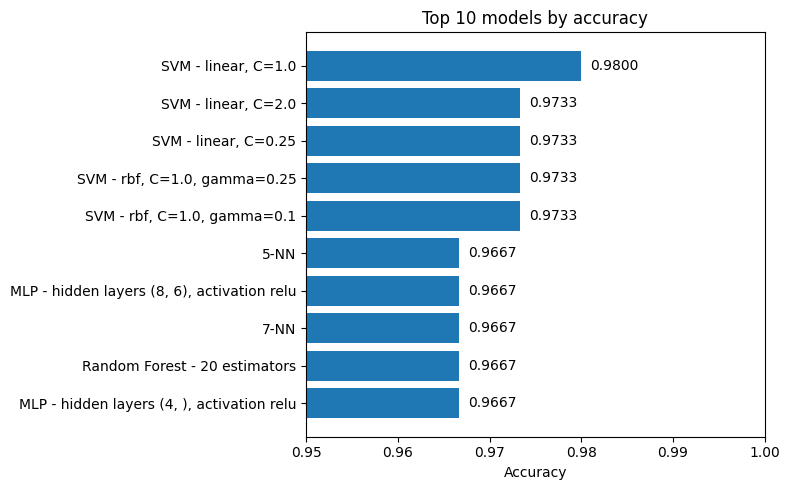

In [15]:
order = np.argsort(accuracies)[::-1][:10]
top_names = [names[i] for i in order]
top_acc = [accuracies[i] for i in order]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top_names, top_acc)
ax.invert_yaxis()
ax.set_xlabel("Accuracy")
ax.set_title("Top 10 models by accuracy")
ax.set_xlim(0.95, 1.0)

for y, v in enumerate(top_acc):
    ax.text(v + 0.001, y, f"{v:.4f}", va="center")

plt.tight_layout()
plt.show()

### Fastest fit time

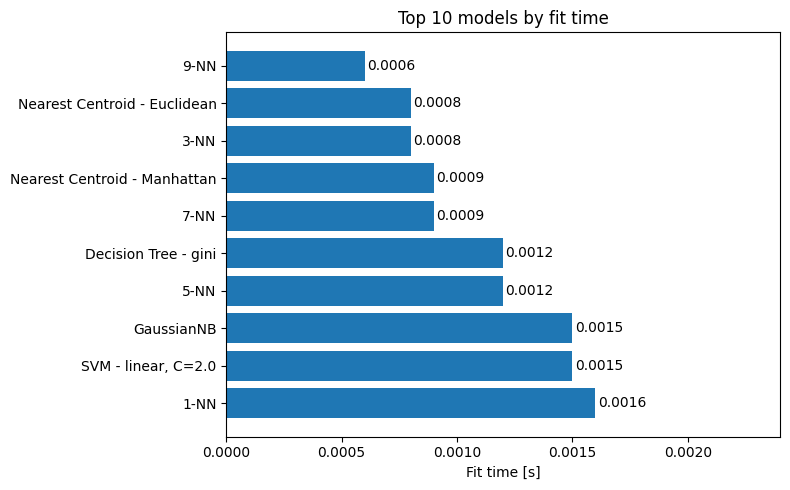

In [30]:
order = np.argsort(fit_times)[:10]
top_names = [names[i] for i in order]
top_fit_time = [fit_times[i] for i in order]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top_names, top_fit_time)
ax.invert_yaxis()
ax.set_xlabel("Fit time [s]")
ax.set_title("Top 10 models by fit time")
ax.set_xlim(0, max(top_fit_time)*1.5)

for y, v in enumerate(top_fit_time):
    ax.text(v + 0.00001, y, f"{v:.4f}", va="center")

plt.tight_layout()
plt.show()

### Fastest score time

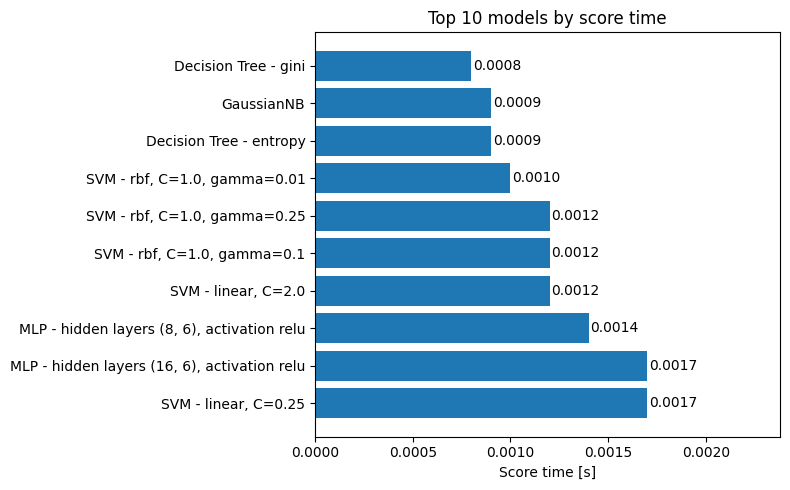

In [26]:
order = np.argsort(score_times)[:10]
top_names = [names[i] for i in order]
top_score_time = [score_times[i] for i in order]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top_names, top_score_time)
ax.invert_yaxis()
ax.set_xlabel("Score time [s]")
ax.set_title("Top 10 models by score time")
ax.set_xlim(0, max(top_score_time)*1.4)

for y, v in enumerate(top_score_time):
    ax.text(v + 0.00001, y, f"{v:.4f}", va="center")

plt.tight_layout()
plt.show()

## Conclusions
On an Iris dataset:
1. The most accurate are SVM models.
2. The fastest in learning are k-NN and Nearest Centroid models.
3. The fastest in evaluation are Decision Trees, Naive Bayes and SVM models.